# Bagging 与随机森林：完整分类实验

本实验使用 `scikit-learn` 自带的**乳腺癌诊断真实数据集**，依次训练并比较：

1. 单棵决策树（基线模型）
2. Bagging 集成模型
3. 随机森林模型

实验重点理解：**Bootstrap 抽样、并行集成、特征随机选择、袋外评估和降低方差**之间的关系。

## 1. 实验目标

完成本实验后，应能够：

- 说明 Bagging 为什么能够降低单个模型的方差；
- 解释 Bootstrap 有放回抽样与袋外样本（OOB）的含义；
- 说明随机森林比普通 Bagging 多加入了哪一种随机性；
- 使用准确率、精确率、召回率、F1、ROC-AUC 和混淆矩阵评价模型；
- 通过交叉验证和参数实验比较模型的性能与稳定性；
- 读取随机森林的特征重要性，并正确理解其局限。

## 2. Bagging 的基本思想

Bagging 是 **Bootstrap Aggregating** 的缩写，核心步骤如下：

1. 从原训练集进行多次**有放回抽样**，得到多个大小相近的训练子集；
2. 每个训练子集独立训练一个基学习器；
3. 分类任务用多数投票，回归任务用平均值，得到最终预测。

对于分类任务，若共有 $B$ 个基学习器，最终预测可写为：

$$
H(x)=\operatorname*{arg\,max}_{c}\sum_{b=1}^{B}I(h_b(x)=c)
$$

其中 $h_b(x)$ 是第 $b$ 个基学习器的预测，$I(\cdot)$ 是指示函数。

单棵深决策树容易因为训练数据稍有变化而产生完全不同的结构，即**方差较大**。Bagging 对许多有差异的树进行投票，能够抵消部分随机波动，因此通常比单棵树更稳定。

## 3. 随机森林的基本思想

随机森林以决策树为基学习器，在 Bagging 的**样本随机性**之外，又加入了**特征随机性**：每次节点分裂时，只从随机选出的部分特征中寻找最佳划分。

这样做会让不同树之间的相关性进一步降低。只要单棵树仍有一定预测能力，相关性更低的多棵树经过投票后，通常能获得更好的泛化能力。

| 对比项 | 单棵决策树 | Bagging（决策树） | 随机森林 |
|---|---|---|---|
| 训练样本 | 原训练集 | Bootstrap 随机样本 | Bootstrap 随机样本 |
| 节点分裂特征 | 全部特征 | 通常为全部特征 | 随机选择的部分特征 |
| 模型数量 | 1 | 多棵树 | 多棵树 |
| 主要目的 | 建立基线 | 降低方差 | 降低方差并减弱树之间的相关性 |
| 可解释性 | 较强 | 较弱 | 可用特征重要性辅助解释 |

## 4. 导入实验所需库

本实验直接使用 `scikit-learn` 的官方实现。树模型不依赖特征之间的距离，也不通过梯度求解参数，因此本实验**不需要标准化**。

In [1]:
%matplotlib inline

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

warnings.filterwarnings("ignore", message="Glyph .* missing from font")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "Noto Sans CJK SC",
    "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42

## 5. 加载真实数据集

乳腺癌数据集包含 569 个样本、30 个由细胞核图像计算得到的数值特征。标签含义为：

- `0`：恶性
- `1`：良性

为了使输出更直观，下面将全部特征名转换为中文。

In [2]:
cancer = load_breast_cancer()

feature_names_zh = [
    "平均半径", "平均纹理", "平均周长", "平均面积", "平均平滑度",
    "平均紧致度", "平均凹度", "平均凹点数", "平均对称性", "平均分形维数",
    "半径标准误", "纹理标准误", "周长标准误", "面积标准误", "平滑度标准误",
    "紧致度标准误", "凹度标准误", "凹点数标准误", "对称性标准误", "分形维数标准误",
    "最大半径", "最大纹理", "最大周长", "最大面积", "最大平滑度",
    "最大紧致度", "最大凹度", "最大凹点数", "最大对称性", "最大分形维数"
]

X = pd.DataFrame(cancer.data, columns=feature_names_zh)
y = pd.Series(cancer.target, name="诊断标签")
data_df = X.copy()
data_df["诊断结果"] = y.map({0: "恶性", 1: "良性"})

print(f"样本数量：{X.shape[0]}")
print(f"特征数量：{X.shape[1]}")
print(f"缺失值总数：{X.isna().sum().sum()}")
display(data_df.head())

样本数量：569
特征数量：30
缺失值总数：0


,平均半径,平均纹理,平均周长,平均面积,平均平滑度,平均紧致度,平均凹度,平均凹点数,平均对称性,平均分形维数,...,最大纹理,最大周长,最大面积,最大平滑度,最大紧致度,最大凹度,最大凹点数,最大对称性,最大分形维数,诊断结果
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,恶性
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,恶性
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,恶性
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,恶性
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,恶性


### 5.1 查看类别分布

先检查类别是否严重不平衡。后续划分数据时使用 `stratify=y`，保证训练集和测试集中的类别比例基本一致。

,样本数,占比（%）
诊断结果,,
恶性,212,37.26
良性,357,62.74


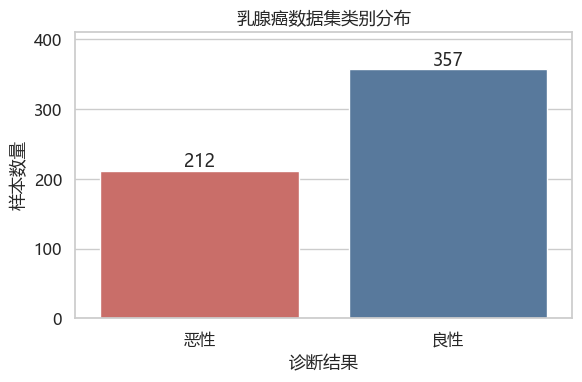

In [3]:
class_counts = data_df["诊断结果"].value_counts().reindex(["恶性", "良性"])
class_ratio = (class_counts / class_counts.sum() * 100).round(2)

display(pd.DataFrame({"样本数": class_counts, "占比（%）": class_ratio}))

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=class_counts.index, y=class_counts.values,
    hue=class_counts.index, palette=["#D95F59", "#4C78A8"], legend=False
)
for i, value in enumerate(class_counts.values):
    ax.text(i, value + 5, str(value), ha="center")
plt.title("乳腺癌数据集类别分布")
plt.xlabel("诊断结果")
plt.ylabel("样本数量")
plt.ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.show()

## 6. 划分训练集和测试集

将 80% 数据用于训练，20% 数据用于最终测试。`random_state` 固定随机过程，使实验可以复现。测试集只用于模型训练完成后的评价。

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"训练集形状：{X_train.shape}")
print(f"测试集形状：{X_test.shape}")
print("训练集类别比例：")
print(y_train.value_counts(normalize=True).sort_index().rename(index={0: "恶性", 1: "良性"}))

训练集形状：(455, 30)
测试集形状：(114, 30)
训练集类别比例：
诊断标签
恶性    0.373626
良性    0.626374
Name: proportion, dtype: float64


## 7. 观察一次 Bootstrap 抽样

Bootstrap 每次从训练集中有放回地抽取与原训练集同样多的样本。由于同一个样本可能被重复抽中，一次抽样通常只覆盖原训练集约 63.2% 的不同样本，剩下约 36.8% 的样本就是该基学习器的**袋外样本**。

下面用一次抽样直观看这个现象。

In [5]:
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_indices = rng.choice(len(X_train), size=len(X_train), replace=True)
unique_indices = np.unique(bootstrap_indices)
oob_indices = np.setdiff1d(np.arange(len(X_train)), unique_indices)

print(f"训练集样本总数：{len(X_train)}")
print(f"抽样次数：{len(bootstrap_indices)}")
print(f"实际被抽中的不同样本数：{len(unique_indices)}")
print(f"不同样本占比：{len(unique_indices) / len(X_train):.2%}")
print(f"袋外样本数：{len(oob_indices)}")
print(f"袋外样本占比：{len(oob_indices) / len(X_train):.2%}")

训练集样本总数：455
抽样次数：455
实际被抽中的不同样本数：285
不同样本占比：62.64%
袋外样本数：170
袋外样本占比：37.36%


## 8. 建立三个对比模型

为保证比较公平，Bagging 和随机森林都使用 200 棵树：

- **决策树**：作为高方差的单模型基线；
- **Bagging**：每棵树使用 Bootstrap 样本，但节点分裂时可查看全部特征；
- **随机森林**：既随机抽取样本，又在每次分裂时随机抽取部分特征。

`oob_score=True` 表示使用袋外样本估计泛化性能。

In [6]:
decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

models = {
    "单棵决策树": decision_tree,
    "Bagging": bagging_model,
    "随机森林": random_forest
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} 训练完成")

单棵决策树 训练完成
Bagging 训练完成
随机森林 训练完成


## 9. 在测试集上进行综合评价

本实验把**恶性（标签 0）视为关注的正类**。各指标含义如下：

- **准确率**：全部样本中预测正确的比例；
- **恶性精确率**：预测为恶性的样本中，真正恶性的比例；
- **恶性召回率**：所有恶性样本中，被模型正确识别的比例；
- **恶性 F1**：恶性精确率与召回率的调和平均；
- **ROC-AUC**：模型在不同阈值下区分恶性和良性的综合能力。

在医学筛查场景中，漏掉恶性病例的代价通常较高，因此不能只看准确率，还应重点观察恶性召回率。

In [7]:
def get_malignant_probability(model, features):
    """返回模型预测为恶性（原标签 0）的概率。"""
    malignant_column = list(model.classes_).index(0)
    return model.predict_proba(features)[:, malignant_column]


def evaluate_model(name, model, features, labels):
    prediction = model.predict(features)
    malignant_probability = get_malignant_probability(model, features)
    malignant_true = (np.asarray(labels) == 0).astype(int)

    return {
        "模型": name,
        "准确率": accuracy_score(labels, prediction),
        "恶性精确率": precision_score(labels, prediction, pos_label=0, zero_division=0),
        "恶性召回率": recall_score(labels, prediction, pos_label=0, zero_division=0),
        "恶性F1": f1_score(labels, prediction, pos_label=0, zero_division=0),
        "ROC-AUC": roc_auc_score(malignant_true, malignant_probability)
    }


results_df = pd.DataFrame([
    evaluate_model(name, model, X_test, y_test)
    for name, model in models.items()
]).set_index("模型")

display(results_df.round(4))

,准确率,恶性精确率,恶性召回率,恶性F1,ROC-AUC
模型,,,,,
单棵决策树,0.9123,0.8478,0.9286,0.8864,0.9157
Bagging,0.9474,0.9286,0.9286,0.9286,0.9931
随机森林,0.9561,0.9512,0.9286,0.9398,0.9931


### 9.1 查看每个类别的详细分类报告

分类报告同时给出恶性和良性两类的精确率、召回率、F1 及样本数，可以防止总体准确率掩盖某一类别表现较差的问题。

In [8]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print("=" * 18, name, "=" * 18)
    print(classification_report(
        y_test, y_pred,
        labels=[0, 1],
        target_names=["恶性（0）", "良性（1）"],
        digits=4
    ))

================== 单棵决策树 ==================
              precision    recall  f1-score   support

       恶性（0）     0.8478    0.9286    0.8864        42
       良性（1）     0.9559    0.9028    0.9286        72

    accuracy                         0.9123       114
   macro avg     0.9019    0.9157    0.9075       114
weighted avg     0.9161    0.9123    0.9130       114

================== Bagging ==================
              precision    recall  f1-score   support

       恶性（0）     0.9286    0.9286    0.9286        42
       良性（1）     0.9583    0.9583    0.9583        72

    accuracy                         0.9474       114
   macro avg     0.9435    0.9435    0.9435       114
weighted avg     0.9474    0.9474    0.9474       114

================== 随机森林 ==================
              precision    recall  f1-score   support

       恶性（0）     0.9512    0.9286    0.9398        42
       良性（1）     0.9589    0.9722    0.9655        72

    accuracy                         0.9561      

### 9.2 混淆矩阵对比

混淆矩阵直接显示每种真实类别被预测成什么。左上角是正确识别的恶性样本，左下角表示恶性样本被误判为良性，属于需要重点关注的漏诊。

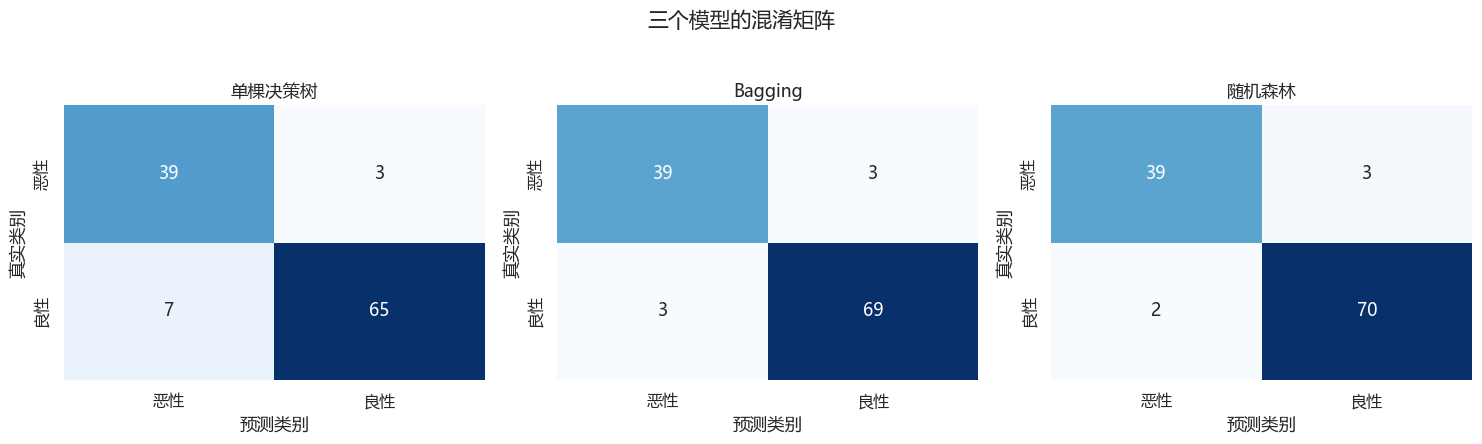

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

for ax, (name, model) in zip(axes, models.items()):
    matrix = confusion_matrix(y_test, model.predict(X_test), labels=[0, 1])
    sns.heatmap(
        matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["恶性", "良性"], yticklabels=["恶性", "良性"]
    )
    ax.set_title(name)
    ax.set_xlabel("预测类别")
    ax.set_ylabel("真实类别")

plt.suptitle("三个模型的混淆矩阵", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

### 9.3 ROC 曲线对比

ROC 曲线越靠近左上角越好，AUC 越接近 1，说明模型区分恶性与良性样本的能力越强。这里统一使用“预测为恶性的概率”绘制曲线。

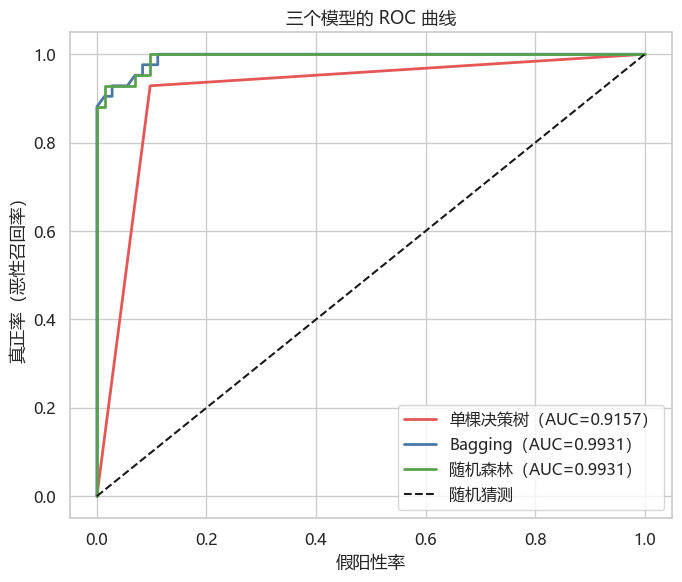

In [10]:
malignant_true = (y_test.to_numpy() == 0).astype(int)
colors = ["#E45756", "#4C78A8", "#59A14F"]

plt.figure(figsize=(7, 6))
for (name, model), color in zip(models.items(), colors):
    malignant_probability = get_malignant_probability(model, X_test)
    fpr, tpr, _ = roc_curve(malignant_true, malignant_probability)
    auc_value = roc_auc_score(malignant_true, malignant_probability)
    plt.plot(fpr, tpr, linewidth=2, color=color, label=f"{name}（AUC={auc_value:.4f}）")

plt.plot([0, 1], [0, 1], "k--", label="随机猜测")
plt.xlabel("假阳性率")
plt.ylabel("真正率（恶性召回率）")
plt.title("三个模型的 ROC 曲线")
plt.legend()
plt.tight_layout()
plt.show()

## 10. 五折交叉验证：比较模型稳定性

单次训练集/测试集划分可能带有偶然性。下面使用分层五折交叉验证，让每个模型在五组不同的验证集上接受评价。除了平均准确率，还应观察标准差：标准差越小，说明模型在不同数据划分下越稳定。

,平均准确率,标准差
模型,,
Bagging,0.9526,0.0181
单棵决策树,0.9104,0.0312
随机森林,0.9543,0.0114


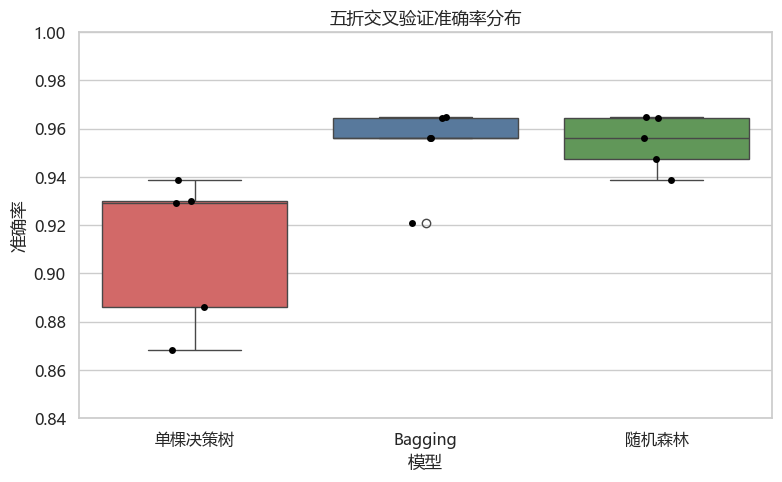

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_records = []

for name, model in models.items():
    scores = cross_val_score(
        clone(model), X, y,
        cv=cv, scoring="accuracy", n_jobs=-1
    )
    for fold, score in enumerate(scores, start=1):
        cv_records.append({"模型": name, "折数": fold, "准确率": score})

cv_df = pd.DataFrame(cv_records)
cv_summary = cv_df.groupby("模型")["准确率"].agg(["mean", "std"])
cv_summary.columns = ["平均准确率", "标准差"]
display(cv_summary.round(4))

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=cv_df, x="模型", y="准确率", hue="模型",
    palette=["#E45756", "#4C78A8", "#59A14F"], legend=False
)
sns.stripplot(data=cv_df, x="模型", y="准确率", color="black", size=5)
plt.title("五折交叉验证准确率分布")
plt.xlabel("模型")
plt.ylabel("准确率")
plt.ylim(0.84, 1.00)
plt.tight_layout()
plt.show()

## 11. 对比实验一：树的数量有什么影响？

`n_estimators` 表示基学习器数量。树太少时，集成结果容易波动；树的数量增加后，性能通常逐渐稳定。继续增加树一般不会像增加单棵树深度那样导致明显过拟合，但会增加训练和预测时间。

In [ ]:
tree_counts = [1, 5, 10, 20, 50, 100, 200]
tree_count_records = []

for count in tree_counts:
    current_models = {
        "Bagging": BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=count, max_samples=0.8,
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        "随机森林": RandomForestClassifier(
            n_estimators=count, max_features="sqrt",
            n_jobs=-1, random_state=RANDOM_STATE
        )
    }

    for name, model in current_models.items():
        model.fit(X_train, y_train)
        tree_count_records.append({
            "模型": name,
            "树的数量": count,
            "测试集准确率": accuracy_score(y_test, model.predict(X_test))
        })

tree_count_df = pd.DataFrame(tree_count_records)
display(tree_count_df.pivot(index="树的数量", columns="模型", values="测试集准确率").round(4))

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=tree_count_df, x="树的数量", y="测试集准确率",
    hue="模型", style="模型", markers=True, dashes=False, linewidth=2
)
plt.xscale("log")
plt.xticks(tree_counts, tree_counts)
plt.title("树的数量对测试集准确率的影响")
plt.xlabel("树的数量（对数坐标）")
plt.ylabel("测试集准确率")
plt.ylim(0.88, 1.00)
plt.tight_layout()
plt.show()

## 12. 对比实验二：Bagging 的抽样比例

`max_samples` 控制每棵树使用多少训练样本：

- 比例较小：树之间差异更大，但每棵树看到的信息更少；
- 比例较大：单棵树的信息更充分，但不同树之间可能更相似。

下面同时比较测试集准确率与 OOB 准确率。

In [ ]:
sample_ratios = [0.4, 0.6, 0.8, 1.0]
sample_records = []

for ratio in sample_ratios:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=150,
        max_samples=ratio,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    sample_records.append({
        "抽样比例": ratio,
        "测试集准确率": accuracy_score(y_test, model.predict(X_test)),
        "OOB准确率": model.oob_score_
    })

sample_df = pd.DataFrame(sample_records)
display(sample_df.round(4))

sample_long = sample_df.melt(
    id_vars="抽样比例", var_name="评价方式", value_name="准确率"
)
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=sample_long, x="抽样比例", y="准确率",
    hue="评价方式", style="评价方式", markers=True, dashes=False, linewidth=2
)
plt.title("Bagging 抽样比例对性能的影响")
plt.xlabel("每棵树使用的训练样本比例")
plt.ylabel("准确率")
plt.ylim(0.90, 1.00)
plt.tight_layout()
plt.show()

## 13. 对比实验三：随机森林的特征随机性

`max_features` 控制每次节点分裂时允许参与竞争的特征数量。若使用全部特征，强特征可能反复被许多树选中，使树之间更加相似；适当减少候选特征可以降低树之间的相关性，但取值过小也可能削弱单棵树。

In [ ]:
feature_settings = [
    ("1个特征", 1),
    ("平方根", "sqrt"),
    ("以2为底的对数", "log2"),
    ("50%特征", 0.5),
    ("全部特征", None)
]
feature_records = []

for setting_name, setting_value in feature_settings:
    model = RandomForestClassifier(
        n_estimators=150,
        max_features=setting_value,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    feature_records.append({
        "每次分裂的候选特征": setting_name,
        "测试集准确率": accuracy_score(y_test, model.predict(X_test)),
        "OOB准确率": model.oob_score_
    })

feature_setting_df = pd.DataFrame(feature_records)
display(feature_setting_df.round(4))

feature_long = feature_setting_df.melt(
    id_vars="每次分裂的候选特征", var_name="评价方式", value_name="准确率"
)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_long, x="每次分裂的候选特征", y="准确率", hue="评价方式"
)
plt.title("随机森林候选特征数量对性能的影响")
plt.xlabel("每次节点分裂可使用的特征")
plt.ylabel("准确率")
plt.ylim(0.90, 1.00)
plt.legend(title="评价方式", loc="lower right")
plt.tight_layout()
plt.show()

## 14. 袋外评估（OOB）是否可靠？

对于某个训练样本，只使用训练时没有抽到该样本的那些树进行预测，就可以得到该样本的 OOB 预测。把所有训练样本的 OOB 预测汇总，可得到 `oob_score_`。

OOB 评估不需要额外划分验证集，常被视为 Bagging 类模型内部的一种泛化性能估计。它不等于最终测试集评价，但二者若比较接近，通常说明 OOB 估计具有参考价值。

In [ ]:
oob_comparison = pd.DataFrame({
    "模型": ["Bagging", "随机森林"],
    "OOB准确率": [bagging_model.oob_score_, random_forest.oob_score_],
    "测试集准确率": [
        accuracy_score(y_test, bagging_model.predict(X_test)),
        accuracy_score(y_test, random_forest.predict(X_test))
    ]
}).set_index("模型")

oob_comparison["绝对差值"] = (
    oob_comparison["OOB准确率"] - oob_comparison["测试集准确率"]
).abs()
display(oob_comparison.round(4))

## 15. 特征重要性分析

随机森林可以汇总特征在各棵树中带来的不纯度下降，得到内置特征重要性。Bagging 可以组合不同类型的基学习器，因此没有统一的内置重要性接口；这里对 Bagging 使用**排列重要性**：随机打乱某一列，观察模型性能下降多少。

注意：重要性表示模型对特征的依赖程度，不代表因果关系；高度相关的特征还可能分摊重要性。

In [ ]:
rf_importance = pd.Series(
    random_forest.feature_importances_, index=X.columns, name="重要性"
).nlargest(10).sort_values()

bagging_permutation = permutation_importance(
    bagging_model, X_test, y_test,
    n_repeats=10, scoring="accuracy",
    n_jobs=-1, random_state=RANDOM_STATE
)
bagging_importance = pd.Series(
    bagging_permutation.importances_mean, index=X.columns, name="重要性"
).nlargest(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.plot.barh(ax=axes[0], color="#59A14F")
axes[0].set_title("随机森林：不纯度特征重要性前10名")
axes[0].set_xlabel("重要性")
axes[0].set_ylabel("特征")

bagging_importance.plot.barh(ax=axes[1], color="#4C78A8")
axes[1].set_title("Bagging：排列重要性前10名")
axes[1].set_xlabel("打乱后准确率的平均下降量")
axes[1].set_ylabel("特征")

plt.tight_layout()
plt.show()

## 16. 自动汇总本次实验结果

下面根据当前实际运行结果生成简短结论，避免只凭某一张图主观判断。

In [ ]:
def names_with_best_score(score_series):
    best_score = score_series.max()
    best_names = score_series.index[np.isclose(score_series.to_numpy(), best_score)]
    return "、".join(best_names), best_score


best_test_model, best_test_score = names_with_best_score(results_df["准确率"])
best_cv_model, best_cv_score = names_with_best_score(cv_summary["平均准确率"])
best_recall_model, best_recall_score = names_with_best_score(results_df["恶性召回率"])

print("本次运行结果汇总")
print("-" * 50)
print(f"测试集准确率最高：{best_test_model}（{best_test_score:.4f}）")
print(f"五折平均准确率最高：{best_cv_model}（{best_cv_score:.4f}）")
print(f"恶性召回率最高：{best_recall_model}（{best_recall_score:.4f}）")
print(f"Bagging 的 OOB 与测试准确率差值：{oob_comparison.loc['Bagging', '绝对差值']:.4f}")
print(f"随机森林的 OOB 与测试准确率差值：{oob_comparison.loc['随机森林', '绝对差值']:.4f}")

## 17. 实验结论

1. **单棵决策树方差较大。** 它容易受训练样本变化影响，因此测试表现和交叉验证稳定性通常弱于集成模型。
2. **Bagging 通过样本随机性降低方差。** 多棵树分别学习不同的 Bootstrap 样本，再通过投票减少单棵树的偶然误差。
3. **随机森林进一步加入特征随机性。** 它不仅改变每棵树看到的样本，还改变节点分裂时可选择的特征，使树之间的相关性进一步下降。
4. **树的数量增加后性能趋于稳定。** 树太少时结果容易波动；达到一定数量后，继续增加树的收益会逐渐减小，但计算开销仍会增加。
5. **OOB 可以作为便捷的内部验证。** 当 OOB 准确率与测试集准确率接近时，它能提供有价值的泛化性能估计。
6. **模型选择不能只看准确率。** 本数据集还应重点观察恶性召回率、F1、AUC 和混淆矩阵中的恶性漏判数量。
7. **特征重要性不是因果关系。** 它只能说明当前模型在当前数据上如何利用特征。

## 18. 可继续完成的练习

- 将 Bagging 的基学习器改为限制深度的决策树，观察偏差与方差如何变化；
- 调整 `max_depth`、`min_samples_leaf` 和 `class_weight`，重点提升恶性召回率；
- 使用 `GridSearchCV` 在交叉验证内部搜索参数，再对保留测试集做一次最终评价；
- 对比随机森林与 Boosting：前者强调并行地降低方差，后者强调串行地纠正前一轮错误；
- 将同一实验迁移到 `load_wine()` 多分类数据集，观察评价指标需要怎样调整。